# **Urban Water Demand Predcition with Climate Signals**

**Project Description** - This project focuses on predicting water consumption using deep learning models that incorporate climate variables such temperature, rainfall, wind speed.

**Gap Addressed** - Water demand is influenced by both weather conditions and human activity patterns, making accurate forecasting complex and challenging.

**Objectives** -

1.   Forecast water demand
2.   Integrate weather and climate data
3.   Support water resource planning


## **Exploratory Data Analysis**

In [ ]:
# import all the libraries
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the datasets
water_consumption_data = pd.read_csv("/content/water_consumption_data.csv")
# rename the columns
# Date represents a timestamp
# Demand is the total water consumption on that date
water_consumption_data = water_consumption_data.rename(columns={"Consumption":"Demand"})
water_consumption_data.head()

,Date,Demand
0,1/7/2009,108637.2762
1,2/7/2009,108638.8474
2,3/7/2009,108633.8275
3,4/7/2009,109082.4222
4,5/7/2009,109071.7580


In [ ]:
# climate data
climate_data = pd.read_csv("/content/london_climate.csv")
climate_data.head()

,Date,Temp_Mean,Temp_Max,Temp_Min,Precipitation,Rainfall,Wind_Speed,ET0,Solar_Radiation
0,2015-01-01 04:00:00,-5.543417,-2.883,-8.433001,0.000000,0.000000,31.056128,1.180087,4.59
1,2015-01-02 04:00:00,-2.745500,-0.633,-3.983000,0.000000,0.000000,23.000591,0.876756,5.99
2,2015-01-03 04:00:00,-1.049667,4.067,-4.033000,18.099997,13.099998,20.188908,0.294635,0.81
3,2015-01-04 04:00:00,1.317000,3.917,-5.633000,8.300000,6.000000,28.146843,0.297200,2.04
4,2015-01-05 04:00:00,-12.037168,-6.483,-14.433001,0.000000,0.000000,29.598919,0.682800,7.04


In [ ]:
# re-create the date format
water_consumption_data["Date"] = pd.to_datetime(water_consumption_data["Date"], dayfirst=True)
# strip the time zone from climate dataset
climate_data["Date"] = pd.to_datetime(climate_data["Date"]).dt.normalize()
climate_data = climate_data.drop(columns=["Temp_Max", "Temp_Min"])

In [ ]:
# check null values - no null values
water_consumption_data.isnull().sum().sum()

np.int64(0)

In [ ]:
# no null values
climate_data.isnull().sum().sum()

np.int64(0)

In [ ]:
# merge two datasets on dates from 2015 Jan-2020 Sep
df = pd.merge(water_consumption_data,climate_data, on="Date",how="inner")
df.head()

,Date,Demand,Temp_Mean,Precipitation,Rainfall,Wind_Speed,ET0,Solar_Radiation
0,2015-01-01,98343.49626,-5.543417,0.000000,0.000000,31.056128,1.180087,4.59
1,2015-01-02,98343.69374,-2.745500,0.000000,0.000000,23.000591,0.876756,5.99
2,2015-01-03,98684.73359,-1.049667,18.099997,13.099998,20.188908,0.294635,0.81
3,2015-01-04,98684.84818,1.317000,8.300000,6.000000,28.146843,0.297200,2.04
4,2015-01-05,98685.22039,-12.037168,0.000000,0.000000,29.598919,0.682800,7.04


In [ ]:
df.dtypes # check data types

,0
Date,datetime64[ns]
Demand,float64
Temp_Mean,float64
Precipitation,float64
Rainfall,float64
Wind_Speed,float64
ET0,float64
Solar_Radiation,float64


In [ ]:
# summary statistics for all numeric columns
summary_stat = df.drop(columns=["Date"]).describe() # drop the date column
print(summary_stat)

              Demand    Temp_Mean  Precipitation     Rainfall   Wind_Speed  \
count    2004.000000  2004.000000    2004.000000  2004.000000  2004.000000   
mean   107978.285595     9.077903       2.781587     2.383333    19.486181   
std      9022.978383    10.803515       5.452121     5.330397     6.482443   
min     94995.010460   -22.166334       0.000000     0.000000     6.162207   
25%    100819.513525     0.324479       0.000000     0.000000    14.618837   
50%    104973.164650     9.141666       0.300000     0.000000    18.766664   
75%    114697.662250    19.127167       3.100000     1.900000    23.863409   
max    135780.426500    27.900337      51.699997    51.699997    50.975285   

               ET0  Solar_Radiation  
count  2004.000000      2004.000000  
mean      2.444930        14.179476  
std       1.725590         8.260710  
min       0.159680         0.730000  
25%       0.842876         6.897500  
50%       2.057534        13.405000  
75%       3.813426        21.04

The descriptive statistics reveal that the average daily water demand for the city is approximately 107,978 m3 across the study period from January 2015 to September 2021. The average daily temperature is around 9.1C and the rainfall is approximately 2.4 mm, while precipitation averages around 2.8 mm. The mean wind speed is around 19.5 kmh. These statistics provides an initial overview of the dataset.

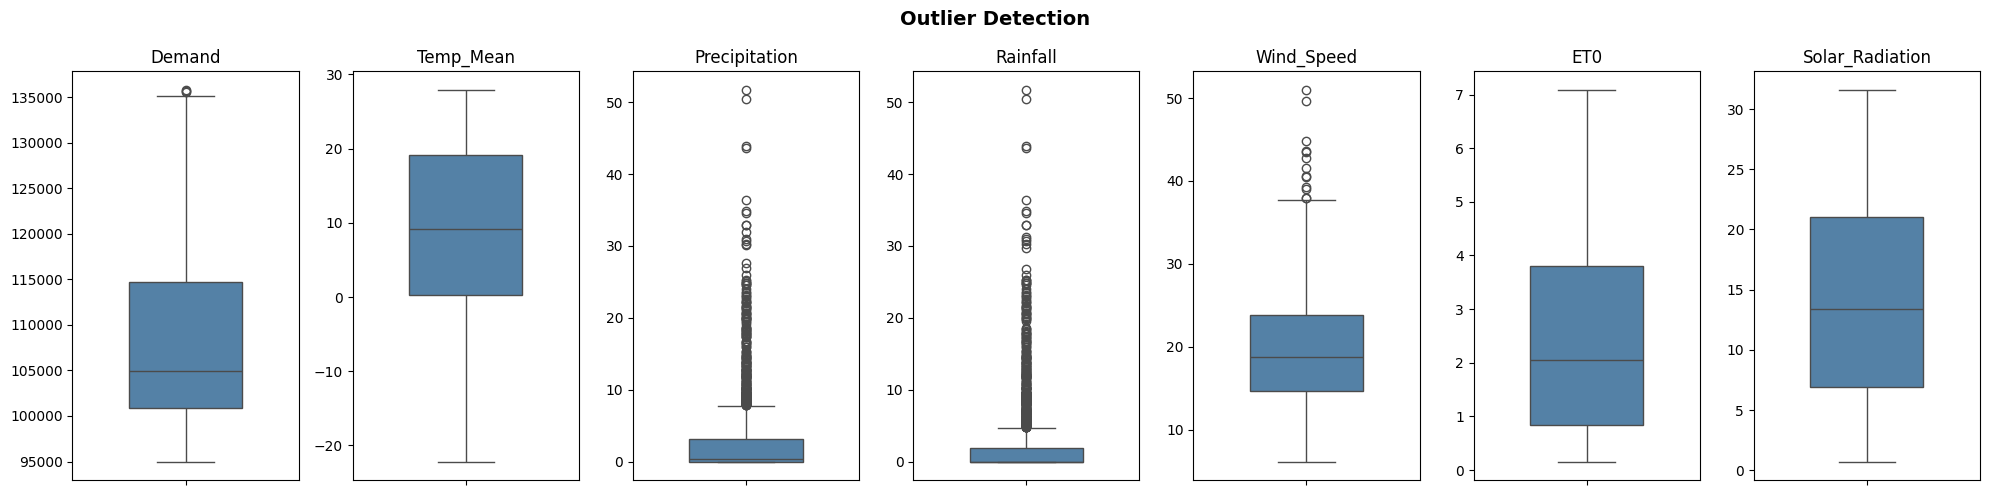

In [ ]:
# outlier detection (exclude date column)
df_1 = pd.DataFrame(df.drop(columns=["Date"]))
fig, axes = plt.subplots(1,7, figsize=(20,5))
axes = axes.flatten()

for i, col in enumerate(df_1.columns):
  sns.boxplot(y=df_1[col], ax=axes[i], color='steelblue', width=0.5)
  axes[i].set_title(f'{col}', fontsize=12)
  axes[i].set_ylabel('')
# give title
plt.suptitle("Outlier Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Outlier detecton is visulaised through box plots. Outliers were identified in precipitation, rainfall, wind speed variables. These outliers are remained as it is, becasue removing the anomalies would result in information loss or give negative impact to the model.

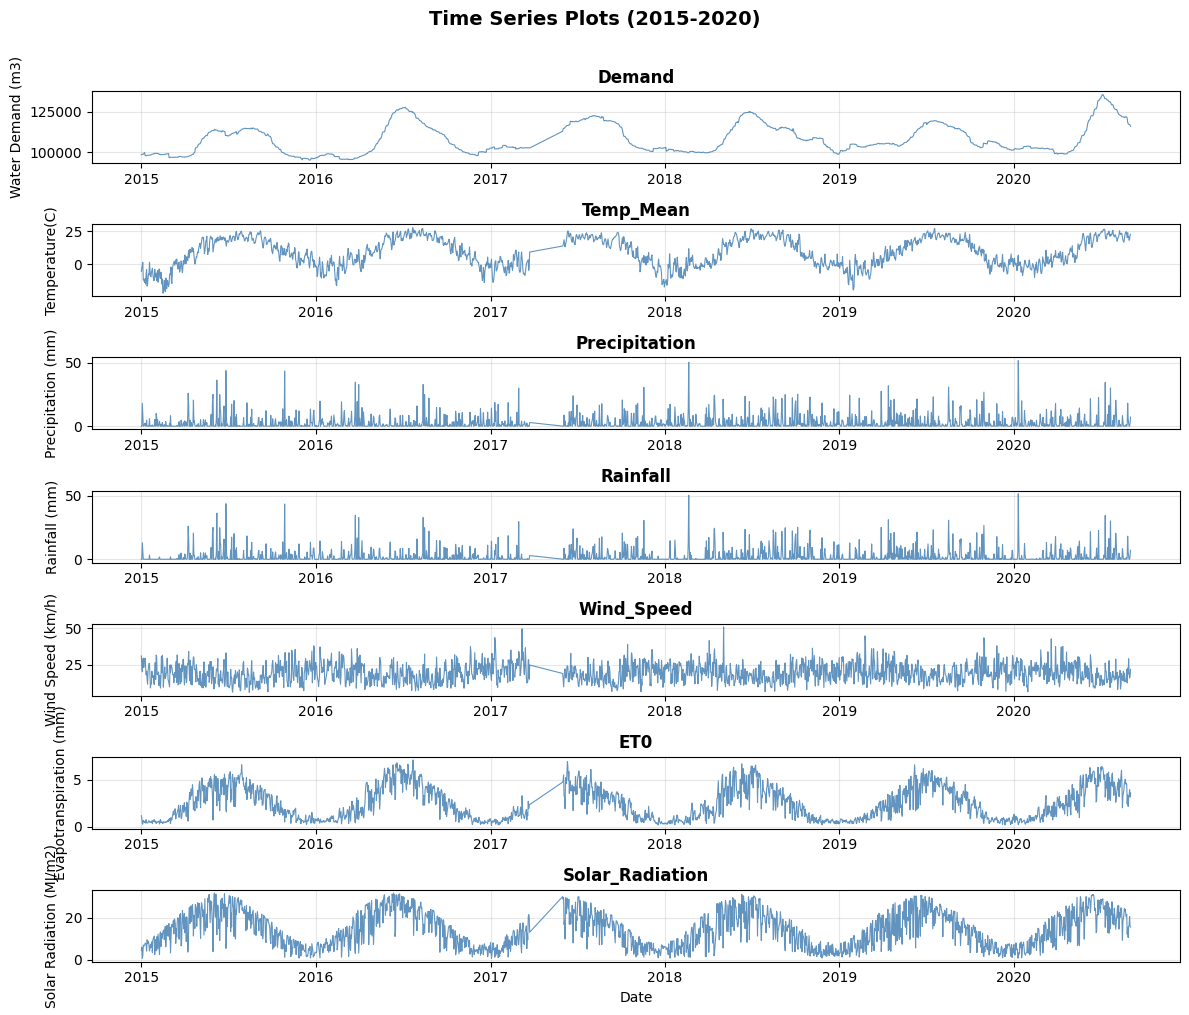

In [ ]:
# all the varaibles
variables = {
    'Demand' : 'Water Demand (m3)',
    'Temp_Mean' : 'Temperature(C)',
    'Precipitation' : 'Precipitation (mm)',
    'Rainfall' : 'Rainfall (mm)',
    'Wind_Speed' :'Wind Speed (km/h)',
    'ET0' : 'Evapotranspiration (mm)',
    'Solar_Radiation':'Solar Radiation (MJ/m2)'
}

fig, axes = plt.subplots(7,1, figsize= (12,10))
# create time series plots for all the variabels
for i,(col,label) in enumerate(variables.items()):
  axes[i].plot(df['Date'], df[col], color='steelblue', linewidth=0.8, alpha=0.85)
  axes[i].set_title(col, fontsize=12, fontweight='bold')
  axes[i].set_ylabel(label, fontsize=10)
  axes[i].set_xlabel('')
  axes[i].grid(True, alpha=0.3)

# show the date label on the bottom plot for visulization purposes
axes[-1].set_xlabel('Date', fontsize=10)
# give a title
plt.suptitle("Time Series Plots (2015-2020)", fontsize=14, fontweight='bold', y= 1.01)
plt.tight_layout()
plt.show()


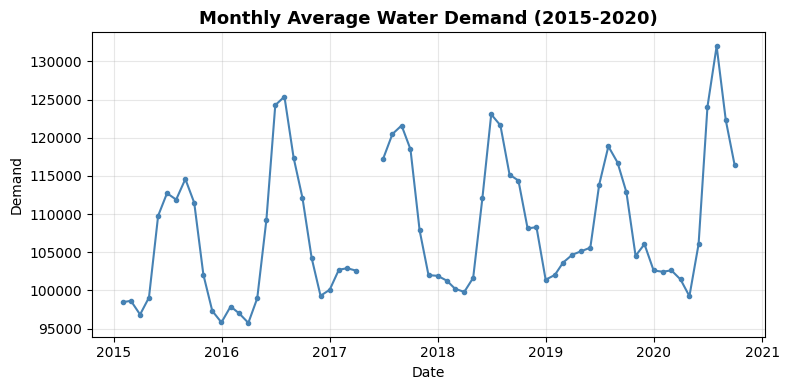

In [ ]:
# monthly data
# group data in time-based(monthly) and take the average demand
# resampling makes the index as Date column
# so reset the index
monthly = df.resample('ME', on='Date')['Demand'].mean().reset_index()

plt.figure(figsize = (8,4))
plt.plot(monthly['Date'], monthly['Demand'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
plt.title('Monthly Average Water Demand (2015-2020)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Based on the plots, water demand(consumption) tends to increase as the average temperature increases. Clear peaks are observed during the summer time (June-August) and the water demand is dropped in winter time(November-January). The same patterns repeats consistently across all years, indicating a strong seasonal influence on water demand. However, rainfall and percipitation don't shows a clear pattern, as the patterns don't follows the similar trend to water demand.

Water demand relatively peaks during the summer months, with the highest observed in 2021 and the second highest in 2016, which is ranging between 125,000 m3 - 135,000m3.  

There is a straight line connecting two data points around mid 2017, which is due to the dataset isn't covering the full year of 2017.

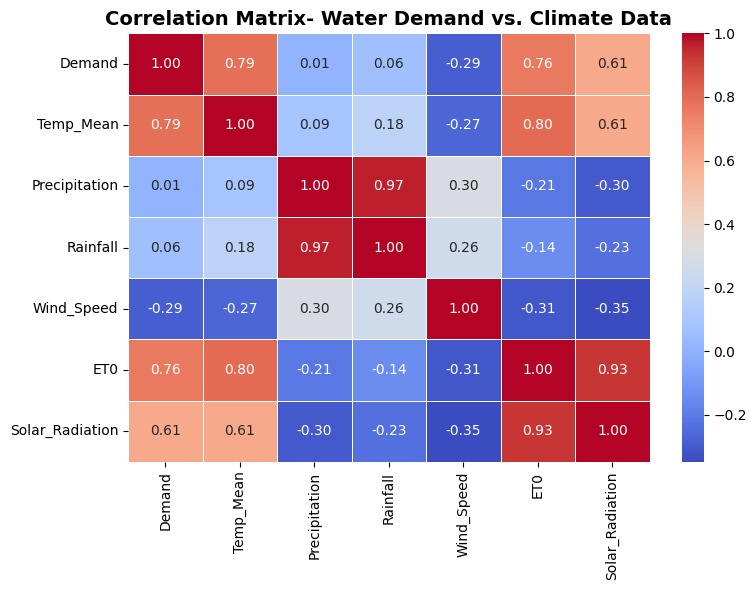

In [ ]:
# correlation matrix
correlation_matrix = df_1.corr()

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix- Water Demand vs. Climate Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The Pearson correlation heatmap reveals the correltion between water demand and climate data. The average temperature shows the strongest positive correlation with water demand, which is 0.79. However, both percipitation and rainfall have low positive correlation, less than 0.1, indicating that the rainfall events have minimal influence on water demand variable. Wind speed shows moderate negative correlation, which is -0.29, meaning that higher wind speeds are associated with lower water demand. Overall based on this heatmap, we can say that the average temperature, ET0 and solar radiation are mainly associated with the water demand.  

## **Model Development**

### **SARIMA-LSTM Model**



The time series plots reveal a strong seasonarity in the water demand series, during summer and winter months across all years. Because of that, SARIMA was selected over ARIMA model as the SARIMA explicitly models seasonal patterns through its seasonal parameters (P,D,Q,m). So, SARIMA is more appropriate for this dataset. **SARIMA model only looks at the history of water demand itself to make future demand predictions**.

According to the time series analysis, the gap was found to occur between February 2017 and June 2017, approximately more than 60 days. Retaining this gap in the dataset would give a period of missing values, which could negatively impact on the accuracy of the model. Also, imputing more than 60 consecutive data points would mislead the model. So, data imputation is not suitable for this case.

So, prior to the model building, this data gap identified during the time series analysis needs to handle. First, the data is examined to identify the exact time period and the length of data before and after the gap to assess the impact of the gap. Based on the results, a subset of data is used for the modelling.

In [ ]:
df_sorted = df.sort_values('Date').reset_index(drop=True) # sort the dataset based on the Date and drop the current index
date_diff = df_sorted['Date'].diff().dt.days # get the difference between each "Date"
# the difference should be one since working on daily water demand
# if the difference is more than one, then there is a gap
gaps = date_diff[date_diff>1]

# get the first and last day in this gap
# create a for loop to go through gaps
for idx in gaps.index:
  # this gives the last day before the gap started
  gap_start = df_sorted.loc[idx-1, 'Date']
  # the first day after the gap occured
  gap_end = df_sorted.loc[idx, 'Date']
  # print both dates
  print(f'Gap starts on: {gap_start.date()}')
  print(f'Gap ends on: {gap_end.date()}')

# reset the index
df_ts = df.set_index('Date')['Demand']
# create two subsets before and after gap occured
df_aftergap = df_ts[gap_end:]
df_beforegap = df_ts[:gap_start]

print()
print('Number of Data points before the gap occure:', len(df_beforegap))
print('Number of Data points after the gap occured', len(df_aftergap))

Gap starts on: 2017-03-24
Gap ends on: 2017-06-01

Number of Data points before the gap occure: 814
Number of Data points after the gap occured 1190


A single data gap is identified in the water demand data from March 2017 to June 2017. The post-gap period has 1190 datapoints, which is significantly larger than the pre-gap set. Therefore, the post-gap subset is selected for SARIMA model development.

In [ ]:
# subset of data we use for building the model
print('Subset:', df_aftergap.index.min().date(), 'to' , df_aftergap.index.max().date())

Subset: 2017-06-01 to 2020-09-02


**Check Stationarity**

SARIMA model assumes that the underlying time series is stationary, which means the mean and variance of the series doesn't change over time. To verify this assumption, two complementary stationarity test are used.

**ADF Test - Augmented Dickey-Fuller Test**

H0 (null hypothesis) - The series is not stationary

H1 (alternative hypothesis) - The series is stationary

**KPSS Test**

H0 (null hypothesis) - The series is stationary

H1 (alternative hypothesis) - The series is not stationary

If the p-value< 0.05, the H0 is rejected. If not, the H1 is rejected.

In [ ]:
# apply adf test to the dataset, we chose
adf_results = adfuller(df_aftergap, autolag= "AIC")
# print the results
print(f'ADF Statistic: {adf_results[0]:.4f}')
print(f'p-value: {adf_results[1]:.4f}')

ADF Statistic: -4.1294
p-value: 0.0009


In [ ]:
# apply kpss test
kpss_result = kpss(df_aftergap, regression='c', nlags='auto')
# print the results
print(f'KPSS Statistic: {kpss_result[0]:.4f}')
print(f'p-value: {kpss_result[1]:.4f}')

KPSS Statistic: 0.2169
p-value: 0.1000


/tmp/ipykernel_1904/2360691135.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df_aftergap, regression='c', nlags='auto')


According to the results,



*   The ADF test returned a p-value of 0.0009(< 0.05), which is less than 0.05. This provides strong evidence to reject the null hypothesis of non-stationarity.
*   The KPSS test returned a p-value of 0.1(>0.05), which is greated than 0.05. This provides strong evidence to confirm the null hypothesis of stationarity.

Both test results are confirmed the stationarity of the unerlying time series in the dataset. Therefore, the SARIMA is used as the model to make future water demand predictions.  



**STL Decomposition**

STL, Seasonal and Trend Decomposition, visually confirms the seasonality in the dataset. The helps to understand how strong the trend, seasonal components. The residual component shows the unexplained variation in the dataset.

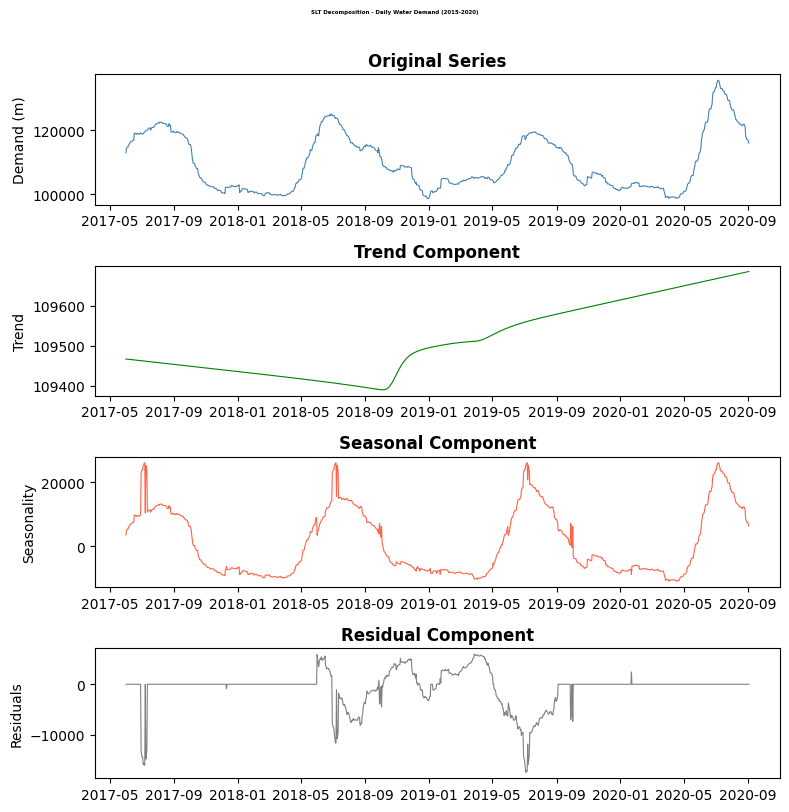

In [ ]:
# fit STL Decomposition
stl = STL(df_aftergap, period=365, robust=True)
slt_result = stl.fit()
# plot all components together
fig, axes = plt.subplots(4,1, figsize=(8,8))
# original water demand
axes[0].plot(df_aftergap, color='steelblue', linewidth = 0.8)
axes[0].set_title('Original Series', fontweight='bold')
axes[0].set_ylabel('Demand (m)')
# trend
axes[1].plot(slt_result.trend, color='green', linewidth = 0.8)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')
# seasonality
axes[2].plot(slt_result.seasonal, color='tomato', linewidth = 0.8)
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonality')
# residuals
axes[3].plot(slt_result.resid, color='gray', linewidth = 0.8)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_ylabel('Residuals')

plt.suptitle("SLT Decomposition - Daily Water Demand (2015-2020)", fontsize=4, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The trend component shows a gradual increase from 109,400 m3 to 109,600 m3, indicating a slow increase in citywide water demand. However, the seasonal component confirms a strong seasonal pattern annually, with summer peak across all the years. The residual component fluctuates around zero.

**SARIMA Parameters**

The next step is to identify the appropriate parameters for the SARIMA model. The AutoCorrelation Function (ACF) and the Partial AutoCorrelation Function (PACF) are used for this. While the ACF measures the correlation between water demand of the current day and all past days across multiple lags, the PACF measures only the direct relationship between the current day and a specific past day. These two plots provide information to identify 'p' and 'q' parameters.

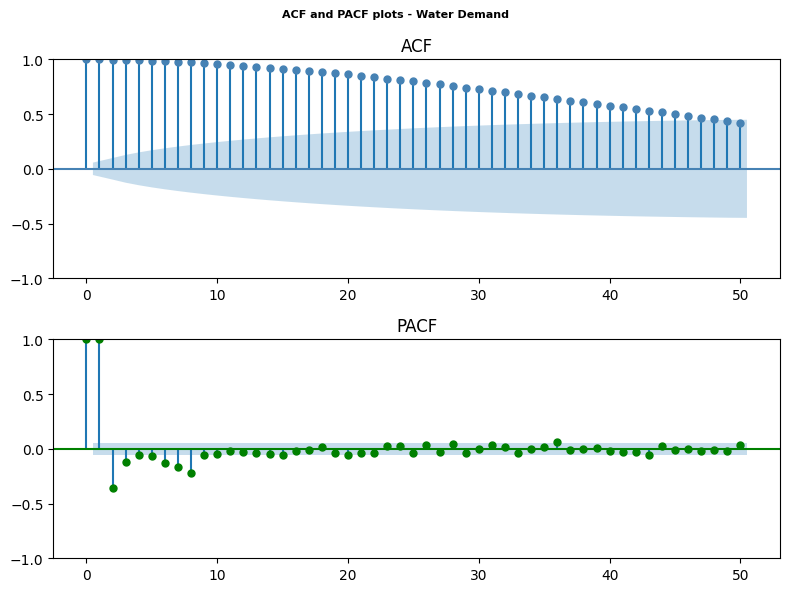

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(8,6))
# plot acf and pacf graphs with 50 time lags
plot_acf(df_aftergap, lags=50, ax=axes[0], color='steelblue', title='ACF')
plot_pacf(df_aftergap, lags=50, ax=axes[1], color='green', title='PACF')

plt.suptitle('ACF and PACF plots - Water Demand', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

According to the results of ACF plot, ACF values are slowly decreased and all the spikes are outside the confidence interval (shade area), indicating that the current day's water demand is correlated with the other days'. The q parameter represents the count of lags before sharp cutoff. Since the curve doesn't cut off sharply, we can choose q = 1 as the initial values.

In the PACF plot, after first two lags, the value is dropped down sharply to near zero and stayed inside the confidence interval. The p parameter represents the count of lags before cutoff and based on the plot, we can get it as 2.

Therefore, p = 2, q = 1.